# Tennessee Eastman: what is actually in this data

The challenge hands us an undocumented industrial sensor stream and asks the system to
work out what each column is, whether the data can be trusted, and what is going wrong,
without the raw rows ever leaving the operator's environment.

This notebook is the human version of that job. It exists so we know what the data does
before we write a pipeline that claims to understand it.

**Ground rule used throughout: the columns are renamed `s01` to `s52` in the first cell.**
The file ships with names (`xmeas_*` and `xmv_*`) that give away the measured versus
manipulated split the system is supposed to infer. Every finding below is therefore made
blind, and the real names are revealed once, in the scorecard section, to grade them.

**How to run.** From the repository root, once:

```
uv venv && uv pip install -r requirements.txt
uv run python scripts/convert_rdata.py     # data/*.RData -> data/parquet/*.parquet
uv run jupyter lab                         # then run this notebook top to bottom
```

The conversion step is the only place R data is touched. Drop any further `.RData` files the
partner sends into `data/` and run it again. Nothing in `data/` is ever committed.

Runtime is well under a minute on a laptop.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({"figure.dpi": 110, "figure.autolayout": True, "axes.grid": True,
                     "grid.alpha": 0.25, "font.size": 9})

ROOT = Path.cwd()
while not (ROOT / "data").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

raw = pd.read_parquet(ROOT / "data" / "parquet" / "fault_free_training.parquet")
raw = raw.sort_values(["simulationRun", "sample"], kind="mergesort").reset_index(drop=True)

TRUE_NAMES = [c for c in raw.columns if c.startswith(("xmeas", "xmv"))]
ANON = [f"s{k:02d}" for k in range(1, len(TRUE_NAMES) + 1)]
REVEAL = dict(zip(ANON, TRUE_NAMES))          # not looked at until the scorecard section

df = raw.rename(columns=dict(zip(TRUE_NAMES, ANON)))
SIGNALS = ANON

print(f"rows {len(df):,}   columns {df.shape[1]}   signals {len(SIGNALS)}")
print("metadata columns:", [c for c in df.columns if c not in SIGNALS])
df.head(3)

rows 250,000   columns 55   signals 52
metadata columns: ['faultNumber', 'simulationRun', 'sample']


,faultNumber,simulationRun,sample,s01,s02,s03,s04,s05,s06,s07,...,s43,s44,s45,s46,s47,s48,s49,s50,s51,s52
0,0,1,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,...,53.744,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447
1,0,1,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,...,53.414,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194
2,0,1,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,...,54.357,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530


## 1. The shape of the file

Three questions before anything else: how is it structured, is anything missing, and is
anything obviously broken. This is the baseline that the data quality checks later have to
improve on.

In [2]:
n_runs = df["simulationRun"].nunique()
n_samples = df["sample"].nunique()
counts = df.groupby("simulationRun").size().unique()

print(f"simulation runs        : {n_runs}")
print(f"samples per run        : {n_samples} (run lengths seen: {counts})")
print(f"faultNumber values     : {sorted(df['faultNumber'].unique())}  <- 0 means normal operation only")
print(f"missing values         : {int(df.isna().sum().sum())}")
print(f"duplicate signal rows  : {int(df[SIGNALS].duplicated().sum())}")
print(f"sample index per run   : {df['sample'].min()} to {df['sample'].max()}, strictly increasing "
      f"in every run: {bool(df.groupby('simulationRun')['sample'].apply(lambda s: s.is_monotonic_increasing).all())}")

# 500 runs x 500 samples x 52 signals, as a cube. Every later analysis uses this.
cube = df[SIGNALS].to_numpy().reshape(n_runs, n_samples, len(SIGNALS))
print(f"\ncube: {cube.shape}  ({cube.nbytes / 1e6:.0f} MB in memory)")

simulation runs        : 500
samples per run        : 500 (run lengths seen: [500])
faultNumber values     : [np.int32(0)]  <- 0 means normal operation only
missing values         : 0
duplicate signal rows  : 0
sample index per run   : 1 to 500, strictly increasing in every run: True

cube: (500, 500, 52)  (104 MB in memory)


**There are no timestamps.** There is a sample index and nothing else, so "duplicate
timestamp", "gap" and "late arrival" checks have nothing to bite on yet. The Tennessee
Eastman simulator samples every 3 minutes, so a 500 sample run is about 25 simulated hours.
We attach that clock ourselves, and the fact that we attached it is itself a data quality
finding worth stating out loud: the file cannot tell us when anything happened.

In [3]:
SAMPLE_MINUTES = 3
df["t_minutes"] = (df["sample"] - 1) * SAMPLE_MINUTES
print(f"one run spans {df.loc[df.simulationRun == 1, 't_minutes'].max() / 60:.1f} simulated hours "
      f"at {SAMPLE_MINUTES} min per sample")
print(f"all {n_runs} runs together: {n_runs * n_samples * SAMPLE_MINUTES / 60 / 24:.0f} simulated days "
      "of normal operation")

one run spans 24.9 simulated hours at 3 min per sample
all 500 runs together: 521 simulated days of normal operation


## 2. A profile per signal

Everything the system will later infer about a column has to come from numbers like these.
This table is the evidence base, and it is also, deliberately, small: 52 rows of statistics
instead of 250,000 rows of measurements. It is the only thing a language model would ever
need to see.

Two columns in it are doing most of the work later:

- `repeat_frac`: the fraction of consecutive samples where the value does not change at all.
- `ac1`: lag-1 autocorrelation within a run, which says whether a signal is slow or fast.

In [4]:
def lag_corr(c, lag):
    """Per-run correlation between a signal and itself `lag` samples later, averaged over runs."""
    a, b = c[:, :-lag, :], c[:, lag:, :]
    a0 = a - a.mean(axis=1, keepdims=True)
    b0 = b - b.mean(axis=1, keepdims=True)
    den = np.sqrt((a0 ** 2).sum(axis=1) * (b0 ** 2).sum(axis=1))
    with np.errstate(invalid="ignore", divide="ignore"):
        out = np.where(den > 0, (a0 * b0).sum(axis=1) / den, np.nan)
    return np.nanmean(out, axis=0)


steps = np.diff(cube, axis=1)
flat = cube.reshape(-1, len(SIGNALS))

profile = pd.DataFrame(index=SIGNALS)
profile["mean"] = flat.mean(axis=0)
profile["sd"] = flat.std(axis=0)
profile["cv"] = profile["sd"] / profile["mean"].abs()
profile["min"] = flat.min(axis=0)
profile["max"] = flat.max(axis=0)
profile["n_unique"] = [np.unique(flat[:, k]).size for k in range(len(SIGNALS))]
profile["repeat_frac"] = (steps == 0).mean(axis=(0, 1))
profile["ac1"] = lag_corr(cube, 1)
profile["ac5"] = lag_corr(cube, 5)
profile["ac20"] = lag_corr(cube, 20)

del steps
profile.round(4)

,mean,sd,cv,min,max,n_unique,repeat_frac,ac1,ac5,ac20
s01,0.2505,0.0309,0.1233,0.1224,0.3917,17399,0.0012,0.6841,0.2975,0.0561
s02,3663.7857,34.0063,0.0093,3511.8000,3808.4000,2384,0.0011,0.3849,-0.0429,0.0039
s03,4508.8198,39.2153,0.0087,4336.9000,4683.7000,2717,0.0010,0.4300,0.1787,0.0102
s04,9.3471,0.0857,0.0092,8.9727,9.7298,5539,0.0003,0.2767,0.2441,0.0356
s05,26.9022,0.2115,0.0079,25.9510,27.8180,1500,0.0015,-0.0021,-0.0026,-0.0011
s06,42.3376,0.2185,0.0052,41.3940,43.2570,1541,0.0014,0.0301,0.0158,-0.0024
s07,2705.0379,7.5256,0.0028,2672.3000,2739.1000,599,0.0212,0.9631,0.8319,0.2865
s08,75.0001,0.5420,0.0072,72.6490,77.5140,3609,0.0005,0.1426,0.1227,0.0073
s09,120.4000,0.0191,0.0002,120.3100,120.4800,18,0.1371,-0.1609,-0.1475,-0.0026
s10,0.3371,0.0125,0.0372,0.2852,0.3948,7782,0.0009,0.5840,0.1738,0.0721


## 3. Finding 1: nineteen signals are sampled more slowly than the rest

`repeat_frac` is not noise. It falls into three sharp groups, and the groups say exactly how
often each instrument actually reports.

repeat_frac value counts (rounded):
repeat_frac
0.00    27
0.01     2
0.02     3
0.14     1
0.50    14
0.80     5


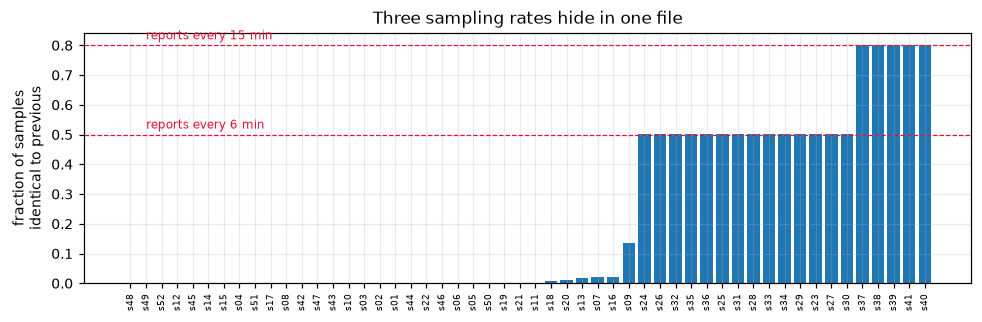


19 signals repeat in long blocks, so they report more slowly:
     repeat_frac  report_every
s23     0.501599           6.0
s24     0.501118           6.0
s25     0.501507           6.0
s26     0.501134           6.0
s27     0.501603           6.0
s28     0.501527           6.0
s29     0.501583           6.0
s30     0.502285           6.0
s31     0.501511           6.0
s32     0.501162           6.0
s33     0.501531           6.0
s34     0.501575           6.0
s35     0.501226           6.0
s36     0.501234           6.0
s37     0.801603          15.1
s38     0.801635          15.1
s39     0.801655          15.1
s40     0.801760          15.1
s41     0.801679          15.1

One signal repeats 2% of the time without being one of them: ['s07', 's09', 's16']. Its repeats are scattered rather than in blocks, and section 5 shows why: it is quantized, with only 599 distinct values available, so it repeats by accident rather than by schedule. A rule that reads repetition as a reporting rate 

In [5]:
groups = profile["repeat_frac"].round(2).value_counts().sort_index()
print("repeat_frac value counts (rounded):")
print(groups.to_string())

profile["report_every"] = (1 / (1 - profile["repeat_frac"]) * SAMPLE_MINUTES).round(1)

fig, ax = plt.subplots(figsize=(9, 3))
order = profile["repeat_frac"].sort_values()
ax.bar(range(len(order)), order.to_numpy(), color="tab:blue")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order.index, rotation=90, fontsize=6)
ax.set_ylabel("fraction of samples\nidentical to previous")
ax.set_title("Three sampling rates hide in one file")
for y, lab in [(0.5, "reports every 6 min"), (0.8, "reports every 15 min")]:
    ax.axhline(y, color="crimson", lw=0.8, ls="--")
    ax.text(1, y + 0.02, lab, color="crimson", fontsize=8)
plt.show()

ANALYZER = profile["repeat_frac"] > 0.3
print(f"\n{int(ANALYZER.sum())} signals repeat in long blocks, so they report more slowly:")
print(profile.loc[ANALYZER, ["repeat_frac", "report_every"]].to_string())

odd = profile[(profile["repeat_frac"] > 0.02) & ~ANALYZER]
print(f"\nOne signal repeats {odd['repeat_frac'].iloc[0]:.0%} of the time without being one of them: "
      f"{list(odd.index)}. Its repeats are scattered rather than in blocks, and section 5 shows why: "
      f"it is quantized, with only {int(odd['n_unique'].iloc[0])} distinct values available, so it "
      f"repeats by accident rather than by schedule. A rule that reads repetition as a reporting "
      f"rate has to exclude it. This is the first check we get wrong, and fix.")

Plotted as traces, the difference is unmistakable. A slow signal is a staircase because the
file repeats the last reading until the instrument reports again, which is what a laboratory
composition analyzer does. Nothing about the column name was needed to see this.

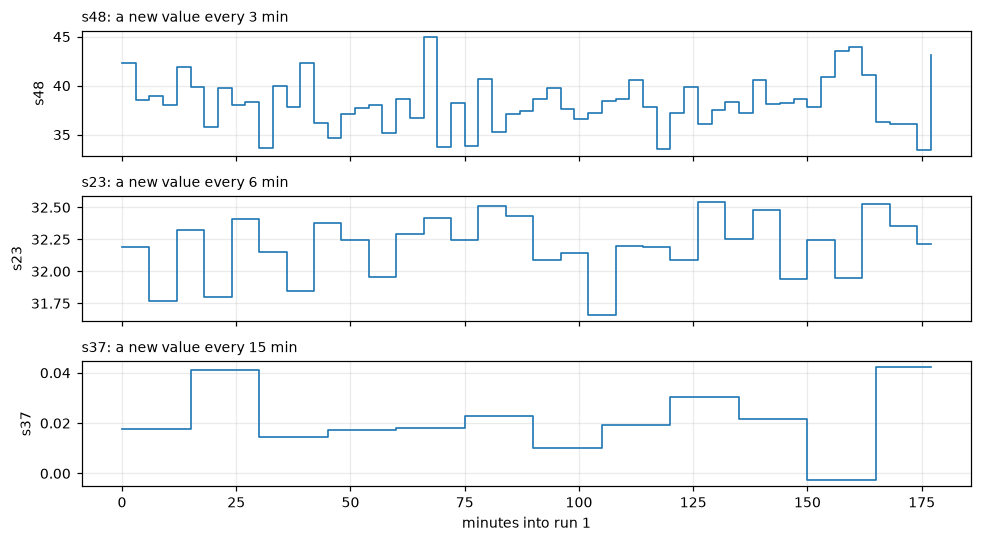

In [6]:
fast_id = profile["repeat_frac"].idxmin()
six_min = profile[(profile["repeat_frac"] > 0.45) & (profile["repeat_frac"] < 0.55)].index[0]
fifteen_min = profile[profile["repeat_frac"] > 0.7].index[0]

fig, axes = plt.subplots(3, 1, figsize=(9, 5), sharex=True)
for ax, sid in zip(axes, [fast_id, six_min, fifteen_min]):
    y = cube[0, :60, SIGNALS.index(sid)]
    ax.step(np.arange(60) * SAMPLE_MINUTES, y, where="post", lw=1.1)
    ax.set_ylabel(sid)
    ax.set_title(f"{sid}: a new value every {profile.loc[sid, 'report_every']:.0f} min", fontsize=9, loc="left")
axes[-1].set_xlabel("minutes into run 1")
plt.show()

## 4. Finding 2: the signals split into slow and fast dynamics

Autocorrelation at lag 1 says whether a signal remembers where it was three minutes ago.
Near 1 means a slow physical quantity, a temperature or a pressure or a level. Near 0 means
the sampling interval is longer than the signal's own dynamics, which is what a tightly
controlled flow looks like.

One caveat to carry forward: a slow analyzer holds its last value for several samples, and
that staircase inflates autocorrelation. Some of the signals that look slow below are slow
instruments rather than slow physics, which is exactly the sort of confusion an evidence
trail is supposed to make visible.

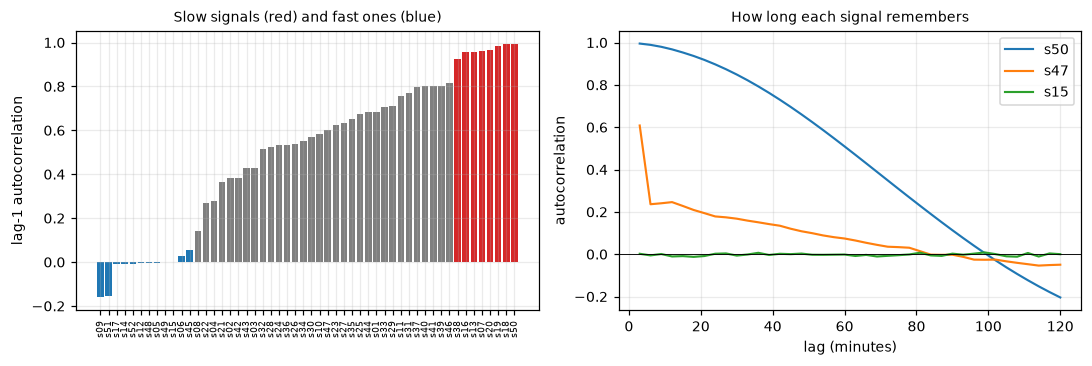

slow (ac1 > 0.9): ['s07', 's13', 's16', 's18', 's19', 's20', 's38', 's50']
fast (|ac1| < 0.1): ['s05', 's06', 's12', 's14', 's15', 's17', 's45', 's48', 's49', 's52']


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

ranked = profile["ac1"].sort_values()
axes[0].bar(range(len(ranked)), ranked.to_numpy(),
            color=["tab:red" if v > 0.9 else "tab:blue" if v < 0.1 else "tab:grey" for v in ranked])
axes[0].set_xticks(range(len(ranked)))
axes[0].set_xticklabels(ranked.index, rotation=90, fontsize=6)
axes[0].set_ylabel("lag-1 autocorrelation")
axes[0].set_title("Slow signals (red) and fast ones (blue)", fontsize=9)

lags = np.arange(1, 41)
slowest = profile["ac1"].idxmax()
fastest = profile["ac1"].abs().idxmin()
middle = (profile["ac1"] - 0.6).abs().idxmin()
for sid in [slowest, middle, fastest]:
    curve = [lag_corr(cube[:60], int(L))[SIGNALS.index(sid)] for L in lags]
    axes[1].plot(lags * SAMPLE_MINUTES, curve, marker="", lw=1.4, label=sid)
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("lag (minutes)")
axes[1].set_ylabel("autocorrelation")
axes[1].set_title("How long each signal remembers", fontsize=9)
axes[1].legend()
plt.show()

print(f"slow (ac1 > 0.9): {list(profile.index[profile['ac1'] > 0.9])}")
print(f"fast (|ac1| < 0.1): {list(profile.index[profile['ac1'].abs() < 0.1])}")

## 5. Finding 3: one instrument is visibly low resolution

Distribution shape carries identity. Most signals are smooth and roughly Gaussian around a
setpoint. One is not: it takes a handful of distinct values across a quarter of a million
samples, which is a quantized instrument rather than a quiet process.

fewest distinct values in 250,000 samples:
     n_unique         mean        sd      min      max
s09        18   120.400022  0.019108   120.31   120.48
s16       518  3102.225506  6.519582  3072.70  3131.30
s07       599  2705.037865  7.525581  2672.30  2739.10
s13       626  2633.769686  7.865832  2598.90  2669.50

s09: 18 distinct values, step size 0.0100, sd 0.0191, coefficient of variation 1.6e-04


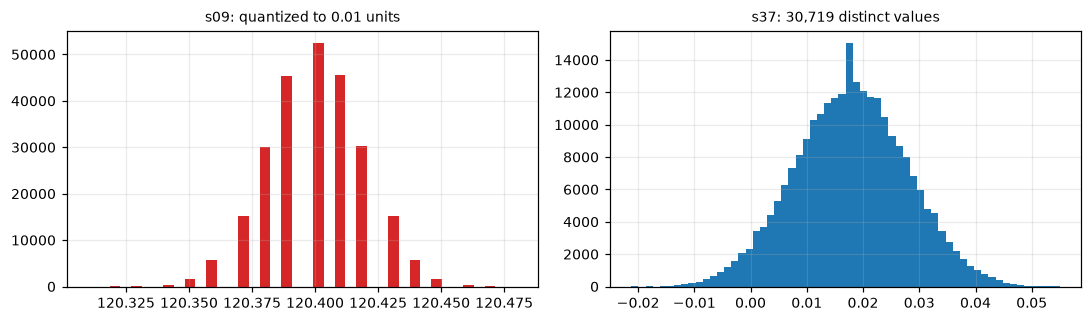

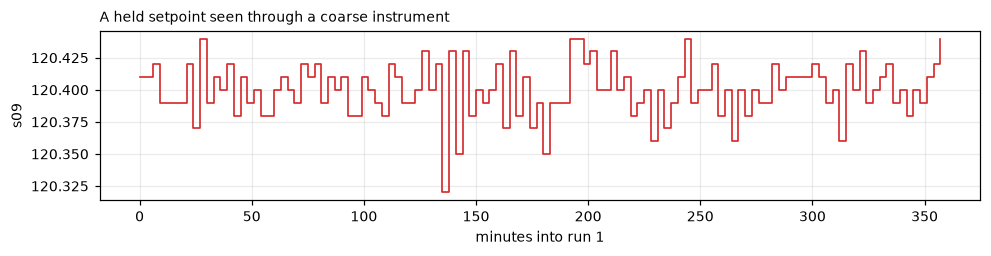

In [8]:
coarse = profile.sort_values("n_unique").head(4)
print("fewest distinct values in 250,000 samples:")
print(coarse[["n_unique", "mean", "sd", "min", "max"]].to_string())

sid = coarse.index[0]
vals = np.unique(flat[:, SIGNALS.index(sid)])
print(f"\n{sid}: {len(vals)} distinct values, step size {np.diff(vals).min():.4f}, "
      f"sd {profile.loc[sid, 'sd']:.4f}, coefficient of variation {profile.loc[sid, 'cv']:.1e}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(flat[:, SIGNALS.index(sid)], bins=40, color="tab:red")
axes[0].set_title(f"{sid}: quantized to {np.diff(vals).min():.2f} units", fontsize=9)
smooth = profile["n_unique"].idxmax()
axes[1].hist(flat[:, SIGNALS.index(smooth)], bins=60, color="tab:blue")
axes[1].set_title(f"{smooth}: {profile.loc[smooth, 'n_unique']:,} distinct values", fontsize=9)
plt.show()

fig, ax = plt.subplots(figsize=(9, 2.4))
ax.step(np.arange(120) * SAMPLE_MINUTES, cube[0, :120, SIGNALS.index(sid)], where="post", lw=1.1, color="tab:red")
ax.set_xlabel("minutes into run 1")
ax.set_ylabel(sid)
ax.set_title("A held setpoint seen through a coarse instrument", fontsize=9, loc="left")
plt.show()

## 6. Finding 4: the correlation structure is sparse, and three pairs are duplicates

A chemical plant under closed-loop control couples everything to everything, so the fear was
a hairball. It is not one. Most pairs are uncorrelated at steady state, a hundred or so carry
real structure, and a handful are so strongly related that one is a function of the other.

pairs with |r| > 0.9: 11   > 0.7: 14   > 0.5: 36   > 0.3: 107   of 1326 pairs


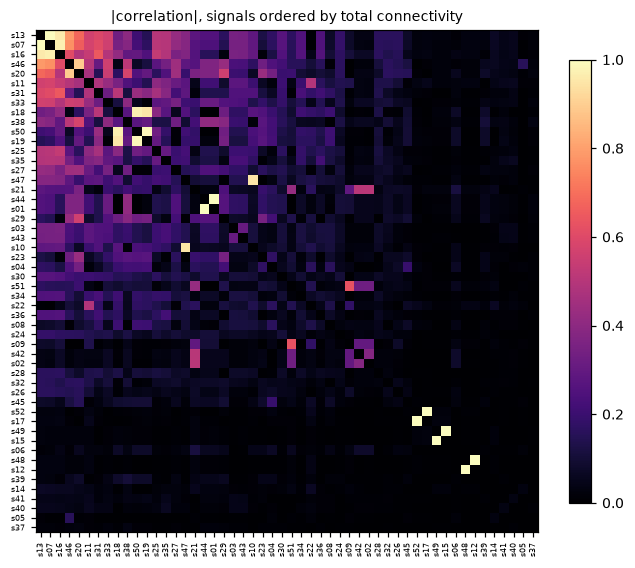


strongest pairs:
  a   b        r
s12 s48  1.00000
s15 s49  1.00000
s17 s52 -0.99924
s07 s13  0.99739
s01 s44  0.99659
s19 s50  0.98606
s18 s50  0.97013
s07 s16  0.96947
s13 s16  0.95976
s18 s19  0.94962
s10 s47  0.94828
s20 s46  0.89418


In [9]:
R = np.corrcoef(flat, rowvar=False)
np.fill_diagonal(R, 0.0)
iu = np.triu_indices(len(SIGNALS), 1)
r = R[iu]
print(f"pairs with |r| > 0.9: {(abs(r) > 0.9).sum()}   > 0.7: {(abs(r) > 0.7).sum()}   "
      f"> 0.5: {(abs(r) > 0.5).sum()}   > 0.3: {(abs(r) > 0.3).sum()}   of {len(r)} pairs")

link_order = np.argsort(-np.abs(R).sum(axis=1))
fig, ax = plt.subplots(figsize=(6.2, 5.4))
im = ax.imshow(np.abs(R)[np.ix_(link_order, link_order)], cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(SIGNALS)))
ax.set_yticks(range(len(SIGNALS)))
ax.set_xticklabels([SIGNALS[i] for i in link_order], rotation=90, fontsize=5)
ax.set_yticklabels([SIGNALS[i] for i in link_order], fontsize=5)
ax.set_title("|correlation|, signals ordered by total connectivity", fontsize=9)
ax.grid(False)
fig.colorbar(im, shrink=0.8)
plt.show()

top = pd.DataFrame({
    "a": [SIGNALS[iu[0][k]] for k in np.argsort(-abs(r))[:12]],
    "b": [SIGNALS[iu[1][k]] for k in np.argsort(-abs(r))[:12]],
    "r": [r[k] for k in np.argsort(-abs(r))[:12]],
})
print("\nstrongest pairs:")
print(top.round(5).to_string(index=False))

The top three pairs are not merely correlated, they are the same quantity twice. Fitting a
straight line through one pair leaves a residual of a few hundredths of a percent, which is
instrument noise, not physics. That means the file contains redundant columns, and it hands
us a lever: in a pair like this, one column is a command and the other is the measurement of
what that command did.

  a   b        r  b = slope*a + c  residual sd / sd(b)  a repeat_frac  b repeat_frac
s12 s48  1.00000 2.943*a -109.043              0.00030        0.00026        0.00010
s15 s49  1.00000  2.314*a -69.180              0.00031        0.00032        0.00017
s17 s52 -0.99924 -2.371*a +72.532              0.03891        0.00048        0.00020


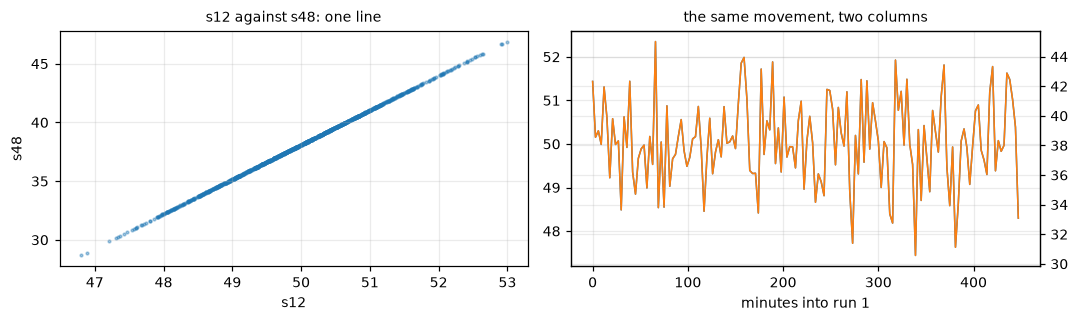

In [10]:
pair_rows = []
for k in np.argsort(-abs(r))[:3]:
    i, j = iu[0][k], iu[1][k]
    a, b = flat[:, i], flat[:, j]
    slope, intercept = np.polyfit(a, b, 1)
    resid = b - (slope * a + intercept)
    pair_rows.append({"a": SIGNALS[i], "b": SIGNALS[j], "r": R[i, j],
                      "b = slope*a + c": f"{slope:.3f}*a {intercept:+.3f}",
                      "residual sd / sd(b)": resid.std() / b.std(),
                      "a repeat_frac": profile.loc[SIGNALS[i], "repeat_frac"],
                      "b repeat_frac": profile.loc[SIGNALS[j], "repeat_frac"]})
duplicates = pd.DataFrame(pair_rows)
print(duplicates.round(5).to_string(index=False))

k = np.argsort(-abs(r))[0]
i, j = iu[0][k], iu[1][k]
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].scatter(flat[::200, i], flat[::200, j], s=3, alpha=0.4)
axes[0].set_xlabel(SIGNALS[i]); axes[0].set_ylabel(SIGNALS[j])
axes[0].set_title(f"{SIGNALS[i]} against {SIGNALS[j]}: one line", fontsize=9)
axes[1].plot(np.arange(150) * SAMPLE_MINUTES, cube[0, :150, i], lw=1.0, label=SIGNALS[i])
ax2 = axes[1].twinx()
ax2.plot(np.arange(150) * SAMPLE_MINUTES, cube[0, :150, j], lw=1.0, color="tab:orange", label=SIGNALS[j])
axes[1].set_xlabel("minutes into run 1")
axes[1].set_title("the same movement, two columns", fontsize=9)
plt.show()

## 7. Finding 5: at steady state, "who moves first" tells us almost nothing

The plan was to orient the correlation graph by time: if A consistently moves before B, A is
upstream of B, and the variables that lead everything are the actuators. This is the standard
move, and on this data it mostly fails. The cell below computes the lagged cross-correlation
for every pair, averaged over runs, takes the lag with the strongest response, and scores
each signal by how often it leads rather than follows.

In [11]:
K, N_LAG_RUNS = 10, 60
sub = cube[:N_LAG_RUNS]
Z = (sub - sub.mean(axis=1, keepdims=True)) / sub.std(axis=1, keepdims=True)
n = Z.shape[1]

C_pos = np.zeros((K + 1, len(SIGNALS), len(SIGNALS)))
for L in range(K + 1):
    C_pos[L] = np.einsum("rti,rtj->ij", Z[:, :n - L, :], Z[:, L:, :]) / (N_LAG_RUNS * (n - L))

lag_values = np.arange(-K, K + 1)
stack = np.stack([C_pos[L] if L >= 0 else C_pos[-L].T for L in lag_values])
pick = np.argmax(np.abs(stack), axis=0)
best_lag = lag_values[pick]
best_r = np.take_along_axis(stack, pick[None], 0)[0]
np.fill_diagonal(best_r, 0.0)
np.fill_diagonal(best_lag, 0)

linked = np.abs(best_r) >= 0.3
lead_score = np.array([np.sign(best_lag[i][linked[i]]).mean() if linked[i].any() else np.nan
                       for i in range(len(SIGNALS))])
print(f"median linked partners per signal (|r| >= 0.3): {np.median(linked.sum(axis=1)):.0f}")
print(f"share of linked pairs whose strongest response is at lag 0: "
      f"{(best_lag[linked] == 0).mean():.0%}")

lead = pd.Series(lead_score, index=SIGNALS).dropna().sort_values(ascending=False)
print("\nmost consistent leaders (1.0 means it precedes every partner):")
print(lead.head(12).round(2).to_string())

median linked partners per signal (|r| >= 0.3): 5
share of linked pairs whose strongest response is at lag 0: 14%

most consistent leaders (1.0 means it precedes every partner):
s04    1.00
s22    1.00
s26    1.00
s30    1.00
s23    0.67
s20    0.59
s46    0.55
s27    0.50
s13    0.46
s07    0.43
s16    0.14
s33    0.13


Two things to take from that. Each signal has only about five linked partners at all, so a
lead score is an average over a handful of noisy lags rather than a measurement of causality,
and the ranking it produces is dominated by signals that turn out not to be actuators, as the
scorecard in the next section grades. The reason is physical rather than technical: this file
is 25 hours of a plant sitting at its setpoint with nothing happening. Causality becomes
visible when something disturbs the plant, and nothing here does.

**This is the most important planning consequence in the notebook.** The faulty runs are not
only needed for the fault demo, they are needed for structure discovery, because an upset is
what excites the plant enough for the lag structure to mean anything.

## 8. The blind scorecard

Now the reveal. Using only what is above, each signal gets a proposed role, and every
proposal cites the statistic behind it:

1. repeating in long blocks means a laboratory analyzer, and the block length gives its
   reporting interval;
2. lag-1 autocorrelation above 0.9 means a slow physical quantity, a temperature, a pressure
   or a level;
3. bounded inside 0 to 100, a width of at least 5 units, no slow memory and no block
   repetition means a percent-scaled command, which is what a valve position looks like;
4. a signal that is an exact straight-line function of another is not an independent signal,
   so the two are reported as one command-and-measurement pair.

Then, and only then, the real column names are used to grade the result.

In [12]:
rng_width = profile["max"] - profile["min"]
is_slow = profile["ac1"] > 0.9
is_percent = (profile["min"] >= 0) & (profile["max"] <= 100) & (rng_width >= 5) & ~is_slow & ~ANALYZER

partner = {}
for a, b in zip(duplicates["a"], duplicates["b"]):
    partner[a], partner[b] = b, a

roles = pd.DataFrame(index=SIGNALS)
roles["proposed_role"] = np.where(
    ANALYZER, "composition analyzer (slow lab sample)",
    np.where(is_percent, "percent-scaled command (valve position)",
             np.where(is_slow, "slow measurement (temperature, pressure or level)",
                      "fast measurement (flow under tight control)")))
roles["evidence"] = [
    f"repeats {profile.loc[s, 'repeat_frac']:.0%} in blocks, reports every {profile.loc[s, 'report_every']:.0f} min"
    if ANALYZER[s] else
    (f"range {profile.loc[s, 'min']:.1f} to {profile.loc[s, 'max']:.1f}, width {rng_width[s]:.1f}, ac1 {profile.loc[s, 'ac1']:.2f}"
     if is_percent[s] else
     (f"ac1 {profile.loc[s, 'ac1']:.2f}, ac20 {profile.loc[s, 'ac20']:.2f}" if is_slow[s] else
      f"ac1 {profile.loc[s, 'ac1']:.2f}, cv {profile.loc[s, 'cv']:.1e}"))
    for s in SIGNALS]
roles["same_signal_as"] = [partner.get(s, "") for s in SIGNALS]

# the reveal
roles["true_name"] = [REVEAL[s] for s in SIGNALS]
truly_cmd = pd.Series([REVEAL[s].startswith("xmv") for s in SIGNALS], index=SIGNALS)

called = roles["proposed_role"].str.startswith("percent-scaled")
hit, missed, wrong = called & truly_cmd, ~called & truly_cmd, called & ~truly_cmd

print(f"analyzers proposed: {int(ANALYZER.sum())}, and every one is truly a measurement: "
      f"{bool((~truly_cmd[ANALYZER]).all())}")
print(f"\ncommands proposed : {int(called.sum())}")
print(f"  correct         : {int(hit.sum())} of {int(truly_cmd.sum())} true commands")
print(f"  wrong           : {int(wrong.sum())}, of which "
      f"{int((roles.loc[wrong, 'same_signal_as'] != '').sum())} are the measurement half of a "
      f"duplicate pair, so the pair is right even though the half is wrong")

print("\nthe commands it missed, with the statistic that hid them:")
print(pd.DataFrame({"width": rng_width[missed].round(2), "ac1": profile.loc[missed, "ac1"].round(2),
                    "true_name": roles.loc[missed, "true_name"]}).to_string())
top_leaders = lead.head(int(truly_cmd.sum())).index
print(f"\nthe lead ranking from section 7, graded: {int(truly_cmd[top_leaders].sum())} of its "
      f"{len(top_leaders)} strongest leaders are truly commands")

print("\nthe measurements it wrongly promoted:")
print(pd.DataFrame({"width": rng_width[wrong].round(2), "ac1": profile.loc[wrong, "ac1"].round(2),
                    "same_signal_as": roles.loc[wrong, "same_signal_as"],
                    "true_name": roles.loc[wrong, "true_name"]}).to_string())

analyzers proposed: 19, and every one is truly a measurement: True

commands proposed : 12
  correct         : 8 of 11 true commands
  wrong           : 4, of which 3 are the measurement half of a duplicate pair, so the pair is right even though the half is wrong

the commands it missed, with the statistic that hid them:
     width   ac1 true_name
s43   4.02  0.43     xmv_2
s46   4.78  0.82     xmv_5
s50  22.98  1.00     xmv_9

the lead ranking from section 7, graded: 1 of its 11 strongest leaders are truly commands

the measurements it wrongly promoted:
     width   ac1 same_signal_as true_name
s12   8.42 -0.00            s48  xmeas_12
s14   9.10 -0.01                 xmeas_14
s15   8.43 -0.00            s49  xmeas_15
s17   5.52 -0.01            s52  xmeas_17


That is the honest version of the result the whole pitch depends on, so it is worth reading
slowly.

The analyzer rule is exact. The command rule gets most of the way and fails in ways the
evidence itself explains: two valves barely move at steady state so their width never reaches
the threshold, one valve is so slow that it reads as a process variable, and most of the
measurements it wrongly promoted are the ones that are numerically identical to a valve.

That last group deserves stating precisely rather than hiding. When two columns are the same
quantity up to a straight line, fault-free data cannot say which is the command and which is
the measurement of it: same noise, same dynamics, same information.

In [13]:
noise_index = pd.Series(np.std(np.diff(cube, n=2, axis=1), axis=(0, 1)) / profile["sd"].to_numpy(),
                        index=SIGNALS)
print("inside a duplicate pair, the two columns are indistinguishable by noise:")
for a, b in zip(duplicates["a"], duplicates["b"]):
    print(f"  {a} noise index {noise_index[a]:.4f}   {b} noise index {noise_index[b]:.4f}   "
          f"difference {abs(noise_index[a] - noise_index[b]):.4f}")
print("\nTelling them apart needs a moment when someone moves the valve, which is to say it "
      "needs the faulty runs.")

inside a duplicate pair, the two columns are indistinguishable by noise:
  s12 noise index 2.4484   s48 noise index 2.4484   difference 0.0000
  s15 noise index 2.4458   s49 noise index 2.4458   difference 0.0000
  s17 noise index 2.4526   s52 noise index 2.4507   difference 0.0019

Telling them apart needs a moment when someone moves the valve, which is to say it needs the faulty runs.


## 9. The baseline: 500 runs of normal operation

Anything that detects drift needs a definition of normal, and 500 independent runs is an
unusually good one. The question is how much the runs differ from each other compared with
how much a signal moves inside one run. If between-run spread is small, a model fitted on
some runs transfers to the others, and a threshold calibrated on history means something.

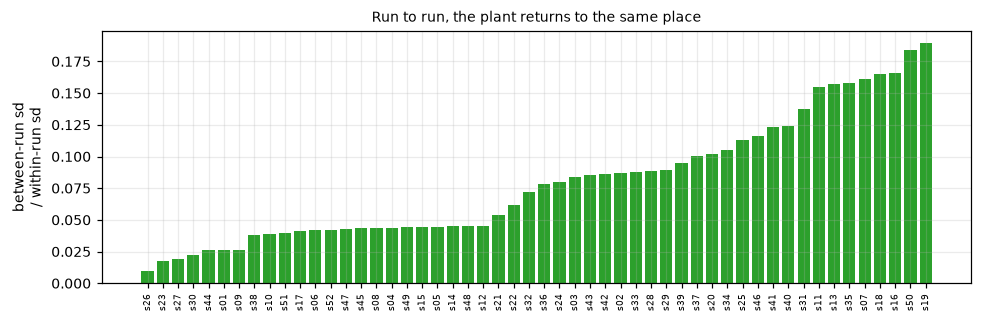

median ratio 0.075: run-to-run drift is about 8% of the noise inside a single run


In [14]:
run_means = cube.mean(axis=1)
between = run_means.std(axis=0)
within = cube.std(axis=1).mean(axis=0)
ratio = pd.Series(between / within, index=SIGNALS).sort_values()

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(range(len(ratio)), ratio.to_numpy(), color="tab:green")
ax.set_xticks(range(len(ratio)))
ax.set_xticklabels(ratio.index, rotation=90, fontsize=6)
ax.set_ylabel("between-run sd\n/ within-run sd")
ax.set_title("Run to run, the plant returns to the same place", fontsize=9)
plt.show()
print(f"median ratio {ratio.median():.3f}: run-to-run drift is about "
      f"{ratio.median() * 100:.0f}% of the noise inside a single run")

So a fault-free model built on some of the runs should hold on the rest. The standard method
for this dataset is principal components with two statistics: T squared for movement inside
the normal subspace, and Q for movement out of it. Both decompose into per-signal
contributions, which is what makes an alarm explainable rather than a score.

components kept for 90% of variance: 31 of 52
thresholds from training (99th percentile): T2 52.1, Q 11.8
held-out normal samples above T2 limit: 1.02%
held-out normal samples above Q limit : 1.03%
above either limit                    : 2.04% -> about 10 false alarms per simulated day


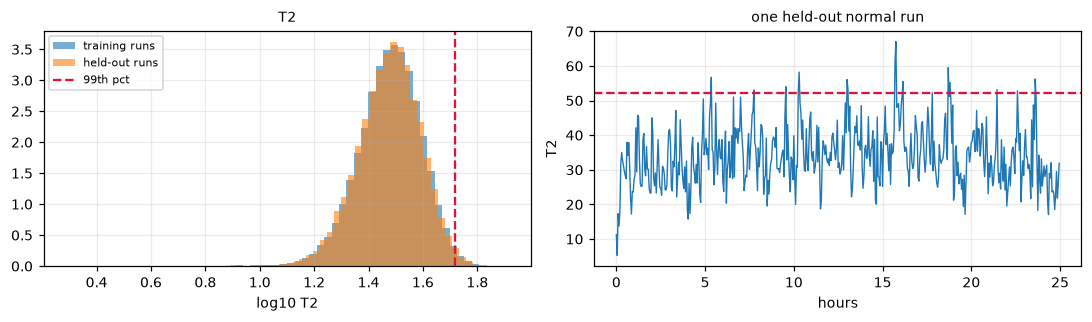

In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

train = cube[:400].reshape(-1, len(SIGNALS))
test = cube[400:].reshape(-1, len(SIGNALS))

scaler = StandardScaler().fit(train)
pca = PCA(n_components=0.90, svd_solver="full").fit(scaler.transform(train))
n_pc = pca.n_components_

def t2_q(block):
    z = scaler.transform(block)
    scores = pca.transform(z)
    recon = pca.inverse_transform(scores)
    t2 = (scores ** 2 / pca.explained_variance_).sum(axis=1)
    q = ((z - recon) ** 2).sum(axis=1)
    return t2, q, (z - recon) ** 2

t2_tr, q_tr, _ = t2_q(train)
t2_te, q_te, sq_te = t2_q(test)
t2_lim, q_lim = np.percentile(t2_tr, 99), np.percentile(q_tr, 99)

print(f"components kept for 90% of variance: {n_pc} of {len(SIGNALS)}")
print(f"thresholds from training (99th percentile): T2 {t2_lim:.1f}, Q {q_lim:.1f}")
print(f"held-out normal samples above T2 limit: {(t2_te > t2_lim).mean():.2%}")
print(f"held-out normal samples above Q limit : {(q_te > q_lim).mean():.2%}")
print(f"above either limit                    : {((t2_te > t2_lim) | (q_te > q_lim)).mean():.2%} "
      f"-> about {((t2_te > t2_lim) | (q_te > q_lim)).mean() * 480:.0f} false alarms per simulated day")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(np.log10(t2_tr), bins=60, alpha=0.6, label="training runs", density=True)
axes[0].hist(np.log10(t2_te), bins=60, alpha=0.6, label="held-out runs", density=True)
axes[0].axvline(np.log10(t2_lim), color="crimson", ls="--", label="99th pct")
axes[0].set_xlabel("log10 T2"); axes[0].legend(fontsize=7); axes[0].set_title("T2", fontsize=9)
one = t2_q(cube[450])[0]
axes[1].plot(np.arange(len(one)) * SAMPLE_MINUTES / 60, one, lw=0.9)
axes[1].axhline(t2_lim, color="crimson", ls="--")
axes[1].set_xlabel("hours"); axes[1].set_ylabel("T2"); axes[1].set_title("one held-out normal run", fontsize=9)
plt.show()

## 10. Data quality: there is nothing broken in this file

This is the finding that shapes the build. The file is simulator output: no missing values,
no gaps, no frozen instruments, no unit changes. The data quality half of the challenge has
nothing to detect here unless we break something on purpose.

Building the checks anyway teaches two things that transfer straight into the pipeline.

First, a baseline has to be learned, not assumed. The obvious frozen-sensor rule, comparing
the distinct values in a window against what the signal's repeat rate predicts, false-alarms
on the quantized signal from section 5, because a signal with eighteen available values
repeats for reasons that have nothing to do with being dead. Learning the expected count from
history instead removes the false alarm without weakening the check.

Second, the check has to respect each instrument's own rate: nineteen signals legitimately
repeat half or four fifths of their samples, and a naive "the value did not change" rule
flags every one of them.

Third, the statistic has to be stationary. Measuring instrument noise as the standard
deviation inside a window sounds right and is wrong: on a slowly drifting signal, the window
standard deviation swings by a factor of five between windows of perfectly healthy data, so
it false-alarms on the slowest signals and still fails to separate a genuinely noisy
instrument. The mean absolute step between consecutive samples removes the drift and leaves
the noise, and on this data it separates cleanly: at most 2.7 times the learned level across
fifty healthy runs, against 5.2 for an instrument whose noise has quadrupled.

In [16]:
WINDOW = 30
REF_RUNS = 60


def window_starts(sample_index, length, w=WINDOW):
    """Only windows whose samples are contiguous: a gap must not be read as noise."""
    if sample_index is None:
        return list(range(0, length - w + 1, w))
    return [s for s in range(0, length - w + 1, w)
            if sample_index[s + w - 1] - sample_index[s] == w - 1]


def window_stat(block, fn, sample_index=None, w=WINDOW):
    starts = window_starts(sample_index, len(block), w)
    if not starts:
        return np.empty((0, block.shape[1]))
    return np.stack([fn(block[s:s + w]) for s in starts])


def n_distinct(chunk):
    return np.array([np.unique(chunk[:, k]).size for k in range(chunk.shape[1])])


def mean_step(chunk):
    return np.abs(np.diff(chunk, axis=0)).mean(axis=0)


distinct_ref = np.median(np.concatenate([window_stat(cube[r], n_distinct) for r in range(REF_RUNS)]), axis=0)
step_ref = np.median(np.concatenate([window_stat(cube[r], mean_step) for r in range(REF_RUNS)]), axis=0)
bounds_lo = profile["min"].to_numpy() - 0.05 * rng_width.to_numpy()
bounds_hi = profile["max"].to_numpy() + 0.05 * rng_width.to_numpy()

affine = [(SIGNALS.index(a), SIGNALS.index(b)) for a, b in zip(duplicates["a"], duplicates["b"])]
affine_fit = [np.polyfit(flat[:, i], flat[:, j], 1) for i, j in affine]
affine_sd = [np.std(flat[:, j] - (m * flat[:, i] + c)) for (i, j), (m, c) in zip(affine, affine_fit)]

print("learned baseline per signal (first four rows):")
print(pd.DataFrame({"distinct_per_window": distinct_ref, "mean_step": step_ref},
                   index=SIGNALS).head(4).round(4).to_string())


def data_quality(block, sample_index):
    """The four baseline checks on one run. Returns one row per failed check."""
    fails = []
    if not np.isfinite(block).all():
        bad = [SIGNALS[k] for k in np.where(~np.isfinite(block).all(axis=0))[0]]
        fails.append(("completeness", "missing values", bad))

    gaps = np.diff(sample_index)
    if (gaps != 1).any():
        fails.append(("timeliness", f"{int((gaps != 1).sum())} gap(s) in the sample index",
                      [f"after sample {int(sample_index[k])}" for k in np.where(gaps != 1)[0]]))

    out = ((block < bounds_lo) | (block > bounds_hi)).any(axis=0)
    if out.any():
        fails.append(("validity", "outside the range seen in 500 normal runs",
                      [SIGNALS[k] for k in np.where(out)[0]]))

    distinct = window_stat(block, n_distinct, sample_index)
    frozen = np.where((distinct < 0.25 * distinct_ref).any(axis=0))[0] if distinct.size else []
    if len(frozen):
        fails.append(("consistency", "instrument stopped producing new values at its own rate",
                      [SIGNALS[k] for k in frozen]))

    steps_w = window_stat(block, mean_step, sample_index)
    noisy = np.where((steps_w > 3.5 * step_ref).any(axis=0))[0] if steps_w.size else []
    if len(noisy):
        fails.append(("consistency", "noise band far above the instrument's own history",
                      [SIGNALS[k] for k in noisy]))

    broken = []
    for (i, j), (m, c), sd in zip(affine, affine_fit, affine_sd):
        resid = block[:, j] - (m * block[:, i] + c)
        if np.abs(resid).max() > 10 * sd:
            broken.append(f"{SIGNALS[i]} vs {SIGNALS[j]}")
    if broken:
        fails.append(("consistency", "a fixed relation between two signals stopped holding", broken))
    return fails


clean = [len(data_quality(cube[r], np.arange(1, n_samples + 1))) for r in range(400, 450)]
print(f"\nchecks failing across 50 held-out normal runs: {sum(clean)}")

learned baseline per signal (first four rows):
     distinct_per_window  mean_step
s01                 30.0     0.0138
s02                 30.0    28.4793
s03                 30.0    32.1172
s04                 30.0     0.0807

checks failing across 50 held-out normal runs: 0


So we inject the faults ourselves, and we say so on stage. Four corruptions, each one a thing
that really happens to industrial data.

In [17]:
base = cube[451].copy()
idx = np.arange(1, n_samples + 1)
victim = SIGNALS.index(profile["ac1"].idxmax())
cases = {}

frozen_case = base.copy()
frozen_case[200:340, victim] = frozen_case[200, victim]
cases["frozen sensor (140 samples held at a plausible value)"] = (frozen_case, idx)

gap_case = np.delete(base.copy(), slice(120, 140), axis=0)
cases["missing block (20 samples never arrived)"] = (gap_case, np.delete(idx, slice(120, 140)))

unit_case = base.copy()
unit_case[:, 3] = unit_case[:, 3] * 1.8
cases["unit change (one signal rescaled)"] = (unit_case, idx)

noise_case = base.copy()
col = noise_case[:, 10]
noise_case[:, 10] = col.mean() + (col - col.mean()) * 4
cases["failing instrument (noise up four times, mean unchanged)"] = (noise_case, idx)

rows = []
for label, (block, index) in cases.items():
    for check, why, which in data_quality(block, index):
        rows.append({"injected": label, "check": check, "finding": why,
                     "signals": ", ".join(map(str, which))[:46]})
print(pd.DataFrame(rows).to_string(index=False))

                                                injected       check                                                 finding          signals
   frozen sensor (140 samples held at a plausible value) consistency instrument stopped producing new values at its own rate              s50
                missing block (20 samples never arrived)  timeliness                            1 gap(s) in the sample index after sample 120
                       unit change (one signal rescaled)    validity               outside the range seen in 500 normal runs              s04
failing instrument (noise up four times, mean unchanged)    validity               outside the range seen in 500 normal runs              s11
failing instrument (noise up four times, mean unchanged) consistency       noise band far above the instrument's own history              s11


The frozen case is the one worth looking at, because it is the trap the whole challenge is
built around. The value stays inside its normal range the entire time, so a range alarm never
fires. What gives it away is the noise floor: a live instrument on a controlled process still
jitters, and a dead one does not.

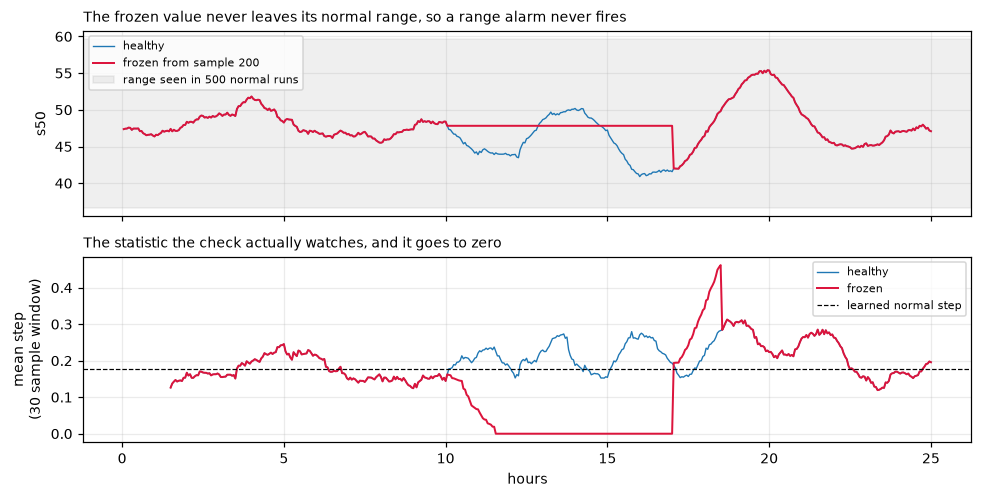

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.6), sharex=True)
t = idx * SAMPLE_MINUTES / 60
axes[0].plot(t, base[:, victim], lw=0.9, label="healthy")
axes[0].plot(t, frozen_case[:, victim], lw=1.3, color="crimson", label="frozen from sample 200")
axes[0].axhspan(profile["min"].iloc[victim], profile["max"].iloc[victim], color="grey", alpha=0.12,
                label="range seen in 500 normal runs")
axes[0].set_ylabel(SIGNALS[victim])
axes[0].legend(fontsize=7, loc="upper left")
axes[0].set_title("The frozen value never leaves its normal range, so a range alarm never fires",
                  fontsize=9, loc="left")

step_series = lambda y: pd.Series(np.abs(np.diff(y, prepend=y[0]))).rolling(WINDOW).mean()
axes[1].plot(t, step_series(base[:, victim]), lw=0.9, label="healthy")
axes[1].plot(t, step_series(frozen_case[:, victim]), lw=1.3, color="crimson", label="frozen")
axes[1].axhline(step_ref[victim], color="k", lw=0.8, ls="--", label="learned normal step")
axes[1].set_ylabel("mean step\n(30 sample window)")
axes[1].set_xlabel("hours")
axes[1].legend(fontsize=7)
axes[1].set_title("The statistic the check actually watches, and it goes to zero",
                  fontsize=9, loc="left")
plt.show()

## 11. What this tells us about the build

### What the file is

500 independent 25 hour runs of a chemical plant in normal operation: 250,000 rows, 52
signals, no missing values, no duplicate rows, no timestamps and `faultNumber` 0 everywhere.
About 521 simulated days in which nothing goes wrong.

### What can be inferred without the column names, and how strongly

| inference | evidence used | how it did |
| --- | --- | --- |
| 19 composition analyzers | values repeat in blocks, 50% and 80% of samples | exact: 19 of 19, all of them measurements |
| reporting interval of each | block length against the 3 minute base rate | 6 minutes and 15 minutes, read straight off the data |
| slow against fast dynamics | lag-1 autocorrelation, 0.00 to 1.00 | clean split, with the caveat that an analyzer staircase inflates it |
| valve positions | bounded 0 to 100, width at least 5, no slow memory | 8 of 11 true commands, 4 wrongly promoted |
| duplicate columns | correlation above 0.999 and a straight-line fit | 3 pairs found, each the same quantity twice |
| which half of a pair is the command | noise index of the two columns | fails: the two are numerically identical |
| upstream and downstream order | lagged cross-correlation, lags -10 to +10 | fails at steady state |
| a definition of normal | 31 components for 90% of variance, T2 and Q | holds on held-out runs: about 2% of samples above the 99th percentile limits, roughly 10 alarms per simulated day |

### Three consequences for what we build

**1. The faulty runs are needed for understanding, not only for the fault demo.** Every
inference that depends on causality fails here, and it fails for a physical reason: a plant
sitting at its setpoint does not reveal what drives what. The same is true of the three
duplicate pairs, where only a moment of actuation can say which column is the command.

**2. Data quality has to be injected, and the checks have to be learned rather than assumed.**
This file contains nothing broken, so every data quality claim we make on stage is a claim
about a corruption we introduced, and we say so. The checks themselves took three attempts,
and the failures are the interesting part: a frozen-sensor rule derived from repeat rates
false-alarmed 5 times across 50 healthy runs, a noise rule based on the standard deviation
inside a window false-alarmed 20 times, and the version that learns both baselines from
history and measures noise as the mean step between samples false-alarms zero times while
still catching a quadrupled noise level.

**3. The derived artifacts are tiny, which is the whole sovereignty argument.** Everything
above came from a profile table of 52 rows by about ten numbers, a 52 by 52 correlation
matrix and a handful of learned baselines. That is kilobytes of derived evidence standing in
for 24 MB of raw measurements, and it is the only thing a language model ever needs to see.

### Next notebook

`02-faults.ipynb`, once the faulty datasets are downloaded: what changes when the plant is
disturbed, whether the lag structure becomes informative, how early a drift can be caught
against a range alarm, and which signals the contribution plots point at.